In [2]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
text = '''
-8.63358361749e-11  814471316.159
-4.83475052593e-11  1524787890.28
-2.06526655169e-11  11737582596.6
3.64072431647e-12  29420430468.7
7.22045711733e-12  47765740033.5
2.11687475721e-11  67478197879
2.82015384875e-11  85826322436.8
3.18094212187e-11  108247741906
4.57858616037e-11  132036309657
4.94547358504e-11  163289300587
6.34311762355e-11  187077868337
6.35625425768e-11  206099714560
6.71469670327e-11  225124375775
8.79356905459e-11  235331540496
1.15438172431e-10  217690917519
1.18769247515e-10  200030589591
1.25520539127e-10  177617615100
1.35649822374e-10  144337829190
1.35762422095e-10  160642268809
1.49321305181e-10  123968539638
1.56058521828e-10  99517510195
1.59305147121e-10  69628852552.5
1.72986013238e-10  50618266302.1
1.83218512895e-10  32284216709.4
2.00394662023e-10  19390610309.3
2.07244478391e-10  11244020485.6
2.24486310689e-10  7861337196.75
2.34836101723e-10  6511078874.23
2.59035658455e-10  10606893730.3
2.86730498197e-10  20819688436.6
3.04080238561e-10  33062093116.2
3.38821944184e-10  63661067332.8
3.59690425833e-10  85417210116.7
3.90904006861e-10  105143742927
4.08234980605e-10  114668741004
4.25528421108e-10  118758925874
4.35901670417e-10  120805425805
4.46251461451e-10  119455167483
4.73866543057e-10  118118984125
4.945895834e-10  118815225734
5.15345465328e-10  124266928899
5.39652930126e-10  143987831723
5.70997877495e-10  182736210757
6.0588971608e-10  235074437799
6.2685203083e-10  270417613599
6.47772120684e-10  299646624542
6.72135885343e-10  327519747176
6.93116966714e-10  365580329579
7.38255379921e-10  401622561981
7.5914262819e-10  426096111369
7.73048693749e-10  439694404357
7.86893767793e-10  444461125885
8.07640266411e-10  448554125748
8.45609830706e-10  446547035719
8.9388696114e-10  437075522510
9.35192292174e-10  418087456203
9.66119682244e-10  396373538315
9.86701972935e-10  376689230400
1.0314275205e-09  352948517531
1.06925164349e-09  329881526327
1.09331983388e-09  314955494960
1.12430821546e-09  302073148532
1.14155004776e-09  298690465243
1.16225901314e-09  297348651900
1.18298674514e-09  298724245160
1.21068158488e-09  308937039866
1.23150314998e-09  323899666142
1.26274957259e-09  348381660508
1.29744905332e-09  372866469867
1.33559690051e-09  396674742569
1.37716965588e-09  416409720359
1.404845729e-09  423905108462
1.41866734477e-09  425275071735
1.44628711803e-09  424618240029
1.47039284166e-09  415127021869
1.50479674812e-09  396812677227
1.54260679614e-09  371707631071
1.56320785346e-09  354740729759
1.62147820914e-09  292288232766
1.64199950831e-09  263772353390
1.67620636526e-09  216925239415
1.70351648929e-09  171431198755
1.71367861412e-09  142906874401
1.74098873815e-09  97412833740.9
1.78199849492e-09  35625613433.9
1.79916995239e-09  22052655382.9
1.81980854294e-09  10520567277.4
1.84048466673e-09  4423292378.31
1.87155280645e-09  3089924013.95
'''

In [4]:
values = [[float(x) for x in line.split()] for line in text.strip().split('\n')]
values = sorted(values, key=lambda x: x[0])
profile = np.array(values)

In [5]:
# validation

# increasing time
assert np.all(np.diff(profile[:, 0]) > 0), "Time values are not strictly increasing"

# add time delay to start time at zero
profile[:, 0] -= profile[0, 0]

Text(0.5, 1.0, 'Omega Laser Power Profile')

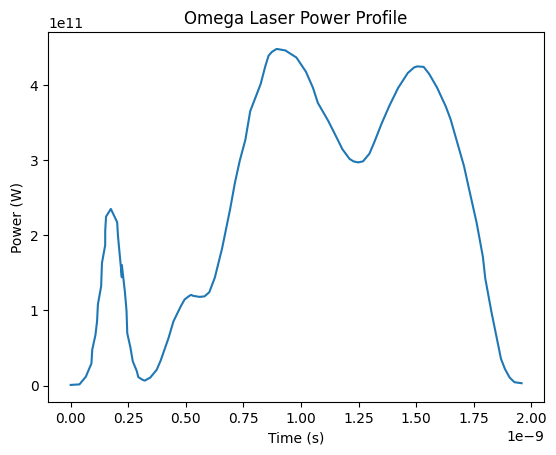

In [6]:
fig, ax = plt.subplots()
ax.plot(profile[:, 0], profile[:, 1])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Power (W)')
ax.set_title('Omega Laser Power Profile')

In [7]:
energy = sp.integrate.simpson(profile[:, 1], profile[:, 0])
print(60*energy)

28137.595777144546


In [8]:
s = '\n'.join(f"{t:15.7e} {p:15.7e}" for t, p in profile)
print(s)

  0.0000000e+00   8.1447132e+08
  3.7988331e-11   1.5247879e+09
  6.5683171e-11   1.1737583e+10
  8.9976560e-11   2.9420430e+10
  9.3556293e-11   4.7765740e+10
  1.0750458e-10   6.7478198e+10
  1.1453737e-10   8.5826322e+10
  1.1814526e-10   1.0824774e+11
  1.3212170e-10   1.3203631e+11
  1.3579057e-10   1.6328930e+11
  1.4976701e-10   1.8707787e+11
  1.4989838e-10   2.0609971e+11
  1.5348280e-10   2.2512438e+11
  1.7427153e-10   2.3533154e+11
  2.0177401e-10   2.1769092e+11
  2.0510508e-10   2.0003059e+11
  2.1185638e-10   1.7761762e+11
  2.2198566e-10   1.4433783e+11
  2.2209826e-10   1.6064227e+11
  2.3565714e-10   1.2396854e+11
  2.4239436e-10   9.9517510e+10
  2.4564098e-10   6.9628853e+10
  2.5932185e-10   5.0618266e+10
  2.6955435e-10   3.2284217e+10
  2.8673050e-10   1.9390610e+10
  2.9358031e-10   1.1244020e+10
  3.1082215e-10   7.8613372e+09
  3.2117194e-10   6.5110789e+09
  3.4537149e-10   1.0606894e+10
  3.7306633e-10   2.0819688e+10
  3.9041607e-10   3.3062093e+10
  4.2515

In [9]:
text = '''
 1.0000000e-03   0.0000000e+00
  9.9992073e-04   1.2591221e-05
  9.9968292e-04   2.5180446e-05
  9.9928662e-04   3.7765678e-05
  9.9873189e-04   5.0344923e-05
  9.9801881e-04   6.2916186e-05
  9.9714751e-04   7.5477474e-05
  9.9611811e-04   8.8026795e-05
  9.9493078e-04   1.0056216e-04
  9.9358571e-04   1.1308158e-04
  9.9208311e-04   1.2558307e-04
  9.9042322e-04   1.3806466e-04
  9.8860630e-04   1.5052435e-04
  9.8663265e-04   1.6296018e-04
  9.8450257e-04   1.7537017e-04
  9.8221640e-04   1.8775236e-04
  9.7977450e-04   2.0010478e-04
  9.7717727e-04   2.1242547e-04
  9.7442511e-04   2.2471249e-04
  9.7151846e-04   2.3696388e-04
  9.6845778e-04   2.4917769e-04
  9.6524356e-04   2.6135201e-04
  9.6187630e-04   2.7348488e-04
  9.5835654e-04   2.8557440e-04
  9.5468484e-04   2.9761864e-04
  9.5086178e-04   3.0961570e-04
  9.4688796e-04   3.2156366e-04
  9.4276402e-04   3.3346065e-04
  9.3849061e-04   3.4530476e-04
  9.3406840e-04   3.5709413e-04
  9.2949810e-04   3.6882689e-04
  9.2478044e-04   3.8050117e-04
  9.1991616e-04   3.9211512e-04
  9.1490602e-04   4.0366690e-04
  9.0975084e-04   4.1515469e-04
  9.0445142e-04   4.2657665e-04
  8.9900860e-04   4.3793098e-04
  8.9342324e-04   4.4921588e-04
  8.8769624e-04   4.6042956e-04
  8.8182850e-04   4.7157024e-04
  8.7582095e-04   4.8263615e-04
  8.6967455e-04   4.9362555e-04
  8.6339026e-04   5.0453668e-04
  8.5696908e-04   5.1536782e-04
  8.5041204e-04   5.2611726e-04
  8.4372016e-04   5.3678328e-04
  8.3689452e-04   5.4736419e-04
  8.2993620e-04   5.5785832e-04
  8.2284629e-04   5.6826401e-04
  8.1562592e-04   5.7857960e-04
  8.0827624e-04   5.8880346e-04
  8.0079841e-04   5.9893397e-04
  7.9319362e-04   6.0896952e-04
  7.8546307e-04   6.1890853e-04
  7.7760799e-04   6.2874940e-04
  7.6962963e-04   6.3849059e-04
  7.6152924e-04   6.4813056e-04
  7.5330812e-04   6.5766776e-04
  7.4496756e-04   6.6710069e-04
  7.3650889e-04   6.7642786e-04
  7.2793345e-04   6.8564779e-04
  7.1924261e-04   6.9475900e-04
  7.1043773e-04   7.0376007e-04
  7.0152021e-04   7.1264956e-04
  6.9249147e-04   7.2142606e-04
  6.8335294e-04   7.3008819e-04
  6.7410607e-04   7.3863456e-04
  6.6475232e-04   7.4706382e-04
  6.5529317e-04   7.5537465e-04
  6.4573014e-04   7.6356571e-04
  6.3606473e-04   7.7163571e-04
  6.2629847e-04   7.7958337e-04
  6.1643291e-04   7.8740743e-04
  6.0646963e-04   7.9510666e-04
  5.9641019e-04   8.0267982e-04
  5.8625619e-04   8.1012572e-04
  5.7600924e-04   8.1744318e-04
  5.6567097e-04   8.2463104e-04
  5.5524302e-04   8.3168816e-04
  5.4472703e-04   8.3861341e-04
  5.3412468e-04   8.4540571e-04
  5.2343765e-04   8.5206398e-04
  5.1266763e-04   8.5858715e-04
  5.0181633e-04   8.6497420e-04
  4.9088547e-04   8.7122411e-04
  4.7987678e-04   8.7733590e-04
  4.6879201e-04   8.8330858e-04
  4.5763291e-04   8.8914122e-04
  4.4640126e-04   8.9483290e-04
  4.3509884e-04   9.0038270e-04
  4.2372743e-04   9.0578975e-04
  4.1228884e-04   9.1105319e-04
  4.0078488e-04   9.1617219e-04
  3.8921739e-04   9.2114593e-04
  3.7758818e-04   9.2597363e-04
  3.6589911e-04   9.3065452e-04
  3.5415203e-04   9.3518786e-04
  3.4234879e-04   9.3957294e-04
  3.3049128e-04   9.4380904e-04
  3.1858138e-04   9.4789551e-04
  3.0662096e-04   9.5183170e-04
  2.9461193e-04   9.5561698e-04
  2.8255619e-04   9.5925075e-04
  2.7045565e-04   9.6273243e-04
  2.5831224e-04   9.6606148e-04
  2.4612787e-04   9.6923737e-04
  2.3390447e-04   9.7225958e-04
  2.2164400e-04   9.7512765e-04
  2.0934838e-04   9.7784112e-04
  1.9701957e-04   9.8039956e-04
  1.8465952e-04   9.8280255e-04
  1.7227020e-04   9.8504973e-04
  1.5985357e-04   9.8714074e-04
  1.4741159e-04   9.8907524e-04
  1.3494624e-04   9.9085292e-04
  1.2245949e-04   9.9247351e-04
  1.0995333e-04   9.9393675e-04
  9.7429736e-05   9.9524241e-04
  8.4890696e-05   9.9639027e-04
  7.2338196e-05   9.9738016e-04
  5.9774228e-05   9.9821192e-04
  4.7200782e-05   9.9888542e-04
  3.4619853e-05   9.9940055e-04
  2.2033436e-05   9.9975723e-04
  9.4435249e-06   9.9995541e-04
 -3.1478832e-06   9.9999505e-04
 -1.5738792e-05   9.9987614e-04
 -2.8327206e-05   9.9959870e-04
 -4.0911129e-05   9.9916279e-04
 -5.3488565e-05   9.9856846e-04
 -6.6057521e-05   9.9781582e-04
 -7.8616004e-05   9.9690497e-04
 -9.1162023e-05   9.9583607e-04
 -1.0369359e-04   9.9460929e-04
 -1.1620871e-04   9.9322482e-04
 -1.2870541e-04   9.9168287e-04
 -1.4118171e-04   9.8998370e-04
 -1.5363562e-04   9.8812757e-04
 -1.6606518e-04   9.8611478e-04
 -1.7846840e-04   9.8394564e-04
 -1.9084333e-04   9.8162051e-04
 -2.0318800e-04   9.7913974e-04
 -2.1550046e-04   9.7650374e-04
 -2.2777875e-04   9.7371292e-04
 -2.4002093e-04   9.7076771e-04
 -2.5222505e-04   9.6766860e-04
 -2.6438919e-04   9.6441607e-04
 -2.7651140e-04   9.6101064e-04
 -2.8858978e-04   9.5745284e-04
 -3.0062240e-04   9.5374324e-04
 -3.1260736e-04   9.4988243e-04
 -3.2454276e-04   9.4587102e-04
 -3.3642671e-04   9.4170965e-04
 -3.4825731e-04   9.3739898e-04
 -3.6003270e-04   9.3293968e-04
 -3.7175101e-04   9.2833248e-04
 -3.8341038e-04   9.2357809e-04
 -3.9500896e-04   9.1867727e-04
 -4.0654492e-04   9.1363079e-04
 -4.1801642e-04   9.0843947e-04
 -4.2942164e-04   9.0310412e-04
 -4.4075878e-04   8.9762559e-04
 -4.5202605e-04   8.9200474e-04
 -4.6322164e-04   8.8624247e-04
 -4.7434380e-04   8.8033969e-04
 -4.8539075e-04   8.7429733e-04
 -4.9636074e-04   8.6811636e-04
 -5.0725204e-04   8.6179776e-04
 -5.1806291e-04   8.5534252e-04
 -5.2879165e-04   8.4875167e-04
 -5.3943655e-04   8.4202625e-04
 -5.4999593e-04   8.3516734e-04
 -5.6046810e-04   8.2817601e-04
 -5.7085142e-04   8.2105338e-04
 -5.8114423e-04   8.1380058e-04
 -5.9134491e-04   8.0641875e-04
 -6.0145183e-04   7.9890907e-04
 -6.1146339e-04   7.9127273e-04
 -6.2137800e-04   7.8351093e-04
 -6.3119411e-04   7.7562491e-04
 -6.4091013e-04   7.6761592e-04
 -6.5052455e-04   7.5948523e-04
 -6.6003583e-04   7.5123412e-04
 -6.6944246e-04   7.4286391e-04
 -6.7874295e-04   7.3437593e-04
 -6.8793584e-04   7.2577151e-04
 -6.9701965e-04   7.1705202e-04
 -7.0599296e-04   7.0821885e-04
 -7.1485433e-04   6.9927340e-04
 -7.2360237e-04   6.9021707e-04
 -7.3223568e-04   6.8105132e-04
 -7.4075291e-04   6.7177759e-04
 -7.4915269e-04   6.6239735e-04
 -7.5743369e-04   6.5291210e-04
 -7.6559461e-04   6.4332332e-04
 -7.7363414e-04   6.3363256e-04
 -7.8155102e-04   6.2384133e-04
 -7.8934399e-04   6.1395119e-04
 -7.9701181e-04   6.0396372e-04
 -8.0455327e-04   5.9388049e-04
 -8.1196717e-04   5.8370310e-04
 -8.1925234e-04   5.7343317e-04
 -8.2640762e-04   5.6307233e-04
 -8.3343188e-04   5.5262221e-04
 -8.4032400e-04   5.4208448e-04
 -8.4708289e-04   5.3146080e-04
 -8.5370748e-04   5.2075286e-04
 -8.6019672e-04   5.0996236e-04
 -8.6654958e-04   4.9909101e-04
 -8.7276505e-04   4.8814053e-04
 -8.7884215e-04   4.7711265e-04
 -8.8477991e-04   4.6600914e-04
 -8.9057739e-04   4.5483173e-04
 -8.9623368e-04   4.4358222e-04
 -9.0174788e-04   4.3226238e-04
 -9.0711910e-04   4.2087401e-04
 -9.1234651e-04   4.0941891e-04
 -9.1742927e-04   3.9789889e-04
 -9.2236658e-04   3.8631580e-04
 -9.2715765e-04   3.7467145e-04
 -9.3180172e-04   3.6296770e-04
 -9.3629806e-04   3.5120641e-04
 -9.4064596e-04   3.3938943e-04
 -9.4484472e-04   3.2751865e-04
 -9.4889367e-04   3.1559594e-04
 -9.5279219e-04   3.0362319e-04
 -9.5653965e-04   2.9160230e-04
 -9.6013545e-04   2.7953518e-04
 -9.6357903e-04   2.6742375e-04
 -9.6686983e-04   2.5526991e-04
 -9.7000735e-04   2.4307560e-04
 -9.7299107e-04   2.3084276e-04
 -9.7582053e-04   2.1857331e-04
 -9.7849528e-04   2.0626921e-04
 -9.8101489e-04   1.9393241e-04
 -9.8337897e-04   1.8156486e-04
 -9.8558714e-04   1.6916853e-04
 -9.8763905e-04   1.5674537e-04
 -9.8953437e-04   1.4429736e-04
 -9.9127281e-04   1.3182648e-04
 -9.9285408e-04   1.1933469e-04
 -9.9427795e-04   1.0682399e-04
 -9.9554417e-04   9.4296347e-05
 -9.9665256e-04   8.1753755e-05
 -9.9760293e-04   6.9198201e-05
 -9.9839514e-04   5.6631677e-05
 -9.9902906e-04   4.4056174e-05
 -9.9950458e-04   3.1473686e-05
 -9.9982164e-04   1.8886208e-05
 -9.9998018e-04   6.2957353e-06
 -9.9998018e-04  -6.2957353e-06
 -9.9982164e-04  -1.8886208e-05
 -9.9950458e-04  -3.1473686e-05
 -9.9902906e-04  -4.4056174e-05
 -9.9839514e-04  -5.6631677e-05
 -9.9760293e-04  -6.9198201e-05
 -9.9665256e-04  -8.1753755e-05
 -9.9554417e-04  -9.4296347e-05
 -9.9427795e-04  -1.0682399e-04
 -9.9285408e-04  -1.1933469e-04
 -9.9127281e-04  -1.3182648e-04
 -9.8953437e-04  -1.4429736e-04
 -9.8763905e-04  -1.5674537e-04
 -9.8558714e-04  -1.6916853e-04
 -9.8337897e-04  -1.8156486e-04
 -9.8101489e-04  -1.9393241e-04
 -9.7849528e-04  -2.0626921e-04
 -9.7582053e-04  -2.1857331e-04
 -9.7299107e-04  -2.3084276e-04
 -9.7000735e-04  -2.4307560e-04
 -9.6686983e-04  -2.5526991e-04
 -9.6357903e-04  -2.6742375e-04
 -9.6013545e-04  -2.7953518e-04
 -9.5653965e-04  -2.9160230e-04
 -9.5279219e-04  -3.0362319e-04
 -9.4889367e-04  -3.1559594e-04
 -9.4484472e-04  -3.2751865e-04
 -9.4064596e-04  -3.3938943e-04
 -9.3629806e-04  -3.5120641e-04
 -9.3180172e-04  -3.6296770e-04
 -9.2715765e-04  -3.7467145e-04
 -9.2236658e-04  -3.8631580e-04
 -9.1742927e-04  -3.9789889e-04
 -9.1234651e-04  -4.0941891e-04
 -9.0711910e-04  -4.2087401e-04
 -9.0174788e-04  -4.3226238e-04
 -8.9623368e-04  -4.4358222e-04
 -8.9057739e-04  -4.5483173e-04
 -8.8477991e-04  -4.6600914e-04
 -8.7884215e-04  -4.7711265e-04
 -8.7276505e-04  -4.8814053e-04
 -8.6654958e-04  -4.9909101e-04
 -8.6019672e-04  -5.0996236e-04
 -8.5370748e-04  -5.2075286e-04
 -8.4708289e-04  -5.3146080e-04
 -8.4032400e-04  -5.4208448e-04
 -8.3343188e-04  -5.5262221e-04
 -8.2640762e-04  -5.6307233e-04
 -8.1925234e-04  -5.7343317e-04
 -8.1196717e-04  -5.8370310e-04
 -8.0455327e-04  -5.9388049e-04
 -7.9701181e-04  -6.0396372e-04
 -7.8934399e-04  -6.1395119e-04
 -7.8155102e-04  -6.2384133e-04
 -7.7363414e-04  -6.3363256e-04
 -7.6559461e-04  -6.4332332e-04
 -7.5743369e-04  -6.5291210e-04
 -7.4915269e-04  -6.6239735e-04
 -7.4075291e-04  -6.7177759e-04
 -7.3223568e-04  -6.8105132e-04
 -7.2360237e-04  -6.9021707e-04
 -7.1485433e-04  -6.9927340e-04
 -7.0599296e-04  -7.0821885e-04
 -6.9701965e-04  -7.1705202e-04
 -6.8793584e-04  -7.2577151e-04
 -6.7874295e-04  -7.3437593e-04
 -6.6944246e-04  -7.4286391e-04
 -6.6003583e-04  -7.5123412e-04
 -6.5052455e-04  -7.5948523e-04
 -6.4091013e-04  -7.6761592e-04
 -6.3119411e-04  -7.7562491e-04
 -6.2137800e-04  -7.8351093e-04
 -6.1146339e-04  -7.9127273e-04
 -6.0145183e-04  -7.9890907e-04
 -5.9134491e-04  -8.0641875e-04
 -5.8114423e-04  -8.1380058e-04
 -5.7085142e-04  -8.2105338e-04
 -5.6046810e-04  -8.2817601e-04
 -5.4999593e-04  -8.3516734e-04
 -5.3943655e-04  -8.4202625e-04
 -5.2879165e-04  -8.4875167e-04
 -5.1806291e-04  -8.5534252e-04
 -5.0725204e-04  -8.6179776e-04
 -4.9636074e-04  -8.6811636e-04
 -4.8539075e-04  -8.7429733e-04
 -4.7434380e-04  -8.8033969e-04
 -4.6322164e-04  -8.8624247e-04
 -4.5202605e-04  -8.9200474e-04
 -4.4075878e-04  -8.9762559e-04
 -4.2942164e-04  -9.0310412e-04
 -4.1801642e-04  -9.0843947e-04
 -4.0654492e-04  -9.1363079e-04
 -3.9500896e-04  -9.1867727e-04
 -3.8341038e-04  -9.2357809e-04
 -3.7175101e-04  -9.2833248e-04
 -3.6003270e-04  -9.3293968e-04
 -3.4825731e-04  -9.3739898e-04
 -3.3642671e-04  -9.4170965e-04
 -3.2454276e-04  -9.4587102e-04
 -3.1260736e-04  -9.4988243e-04
 -3.0062240e-04  -9.5374324e-04
 -2.8858978e-04  -9.5745284e-04
 -2.7651140e-04  -9.6101064e-04
 -2.6438919e-04  -9.6441607e-04
 -2.5222505e-04  -9.6766860e-04
 -2.4002093e-04  -9.7076771e-04
 -2.2777875e-04  -9.7371292e-04
 -2.1550046e-04  -9.7650374e-04
 -2.0318800e-04  -9.7913974e-04
 -1.9084333e-04  -9.8162051e-04
 -1.7846840e-04  -9.8394564e-04
 -1.6606518e-04  -9.8611478e-04
 -1.5363562e-04  -9.8812757e-04
 -1.4118171e-04  -9.8998370e-04
 -1.2870541e-04  -9.9168287e-04
 -1.1620871e-04  -9.9322482e-04
 -1.0369359e-04  -9.9460929e-04
 -9.1162023e-05  -9.9583607e-04
 -7.8616004e-05  -9.9690497e-04
 -6.6057521e-05  -9.9781582e-04
 -5.3488565e-05  -9.9856846e-04
 -4.0911129e-05  -9.9916279e-04
 -2.8327206e-05  -9.9959870e-04
 -1.5738792e-05  -9.9987614e-04
 -3.1478832e-06  -9.9999505e-04
  9.4435249e-06  -9.9995541e-04
  2.2033436e-05  -9.9975723e-04
  3.4619853e-05  -9.9940055e-04
  4.7200782e-05  -9.9888542e-04
  5.9774228e-05  -9.9821192e-04
  7.2338196e-05  -9.9738016e-04
  8.4890696e-05  -9.9639027e-04
  9.7429736e-05  -9.9524241e-04
  1.0995333e-04  -9.9393675e-04
  1.2245949e-04  -9.9247351e-04
  1.3494624e-04  -9.9085292e-04
  1.4741159e-04  -9.8907524e-04
  1.5985357e-04  -9.8714074e-04
  1.7227020e-04  -9.8504973e-04
  1.8465952e-04  -9.8280255e-04
  1.9701957e-04  -9.8039956e-04
  2.0934838e-04  -9.7784112e-04
  2.2164400e-04  -9.7512765e-04
  2.3390447e-04  -9.7225958e-04
  2.4612787e-04  -9.6923737e-04
  2.5831224e-04  -9.6606148e-04
  2.7045565e-04  -9.6273243e-04
  2.8255619e-04  -9.5925075e-04
  2.9461193e-04  -9.5561698e-04
  3.0662096e-04  -9.5183170e-04
  3.1858138e-04  -9.4789551e-04
  3.3049128e-04  -9.4380904e-04
  3.4234879e-04  -9.3957294e-04
  3.5415203e-04  -9.3518786e-04
  3.6589911e-04  -9.3065452e-04
  3.7758818e-04  -9.2597363e-04
  3.8921739e-04  -9.2114593e-04
  4.0078488e-04  -9.1617219e-04
  4.1228884e-04  -9.1105319e-04
  4.2372743e-04  -9.0578975e-04
  4.3509884e-04  -9.0038270e-04
  4.4640126e-04  -8.9483290e-04
  4.5763291e-04  -8.8914122e-04
  4.6879201e-04  -8.8330858e-04
  4.7987678e-04  -8.7733590e-04
  4.9088547e-04  -8.7122411e-04
  5.0181633e-04  -8.6497420e-04
  5.1266763e-04  -8.5858715e-04
  5.2343765e-04  -8.5206398e-04
  5.3412468e-04  -8.4540571e-04
  5.4472703e-04  -8.3861341e-04
  5.5524302e-04  -8.3168816e-04
  5.6567097e-04  -8.2463104e-04
  5.7600924e-04  -8.1744318e-04
  5.8625619e-04  -8.1012572e-04
  5.9641019e-04  -8.0267982e-04
  6.0646963e-04  -7.9510666e-04
  6.1643291e-04  -7.8740743e-04
  6.2629847e-04  -7.7958337e-04
  6.3606473e-04  -7.7163571e-04
  6.4573014e-04  -7.6356571e-04
  6.5529317e-04  -7.5537465e-04
  6.6475232e-04  -7.4706382e-04
  6.7410607e-04  -7.3863456e-04
  6.8335294e-04  -7.3008819e-04
  6.9249147e-04  -7.2142606e-04
  7.0152021e-04  -7.1264956e-04
  7.1043773e-04  -7.0376007e-04
  7.1924261e-04  -6.9475900e-04
  7.2793345e-04  -6.8564779e-04
  7.3650889e-04  -6.7642786e-04
  7.4496756e-04  -6.6710069e-04
  7.5330812e-04  -6.5766776e-04
  7.6152924e-04  -6.4813056e-04
  7.6962963e-04  -6.3849059e-04
  7.7760799e-04  -6.2874940e-04
  7.8546307e-04  -6.1890853e-04
  7.9319362e-04  -6.0896952e-04
  8.0079841e-04  -5.9893397e-04
  8.0827624e-04  -5.8880346e-04
  8.1562592e-04  -5.7857960e-04
  8.2284629e-04  -5.6826401e-04
  8.2993620e-04  -5.5785832e-04
  8.3689452e-04  -5.4736419e-04
  8.4372016e-04  -5.3678328e-04
  8.5041204e-04  -5.2611726e-04
  8.5696908e-04  -5.1536782e-04
  8.6339026e-04  -5.0453668e-04
  8.6967455e-04  -4.9362555e-04
  8.7582095e-04  -4.8263615e-04
  8.8182850e-04  -4.7157024e-04
  8.8769624e-04  -4.6042956e-04
  8.9342324e-04  -4.4921588e-04
  8.9900860e-04  -4.3793098e-04
  9.0445142e-04  -4.2657665e-04
  9.0975084e-04  -4.1515469e-04
  9.1490602e-04  -4.0366690e-04
  9.1991616e-04  -3.9211512e-04
  9.2478044e-04  -3.8050117e-04
  9.2949810e-04  -3.6882689e-04
  9.3406840e-04  -3.5709413e-04
  9.3849061e-04  -3.4530476e-04
  9.4276402e-04  -3.3346065e-04
  9.4688796e-04  -3.2156366e-04
  9.5086178e-04  -3.0961570e-04
  9.5468484e-04  -2.9761864e-04
  9.5835654e-04  -2.8557440e-04
  9.6187630e-04  -2.7348488e-04
  9.6524356e-04  -2.6135201e-04
  9.6845778e-04  -2.4917769e-04
  9.7151846e-04  -2.3696388e-04
  9.7442511e-04  -2.2471249e-04
  9.7717727e-04  -2.1242547e-04
  9.7977450e-04  -2.0010478e-04
  9.8221640e-04  -1.8775236e-04
  9.8450257e-04  -1.7537017e-04
  9.8663265e-04  -1.6296018e-04
  9.8860630e-04  -1.5052435e-04
  9.9042322e-04  -1.3806466e-04
  9.9208311e-04  -1.2558307e-04
  9.9358571e-04  -1.1308158e-04
  9.9493078e-04  -1.0056216e-04
  9.9611811e-04  -8.8026795e-05
  9.9714751e-04  -7.5477474e-05
  9.9801881e-04  -6.2916186e-05
  9.9873189e-04  -5.0344923e-05
  9.9928662e-04  -3.7765678e-05
  9.9968292e-04  -2.5180446e-05
  9.9992073e-04  -1.2591221e-05
  1.0000000e-03  -2.4492936e-19

  9.5500000e-04   0.0000000e+00
  9.5492429e-04   1.2024616e-05
  9.5469719e-04   2.4047326e-05
  9.5431872e-04   3.6066223e-05
  9.5378896e-04   4.8079402e-05
  9.5310797e-04   6.0084958e-05
  9.5227587e-04   7.2080988e-05
  9.5129279e-04   8.4065590e-05
  9.5015889e-04   9.6036863e-05
  9.4887435e-04   1.0799291e-04
  9.4743937e-04   1.1993184e-04
  9.4585417e-04   1.3185175e-04
  9.4411902e-04   1.4375075e-04
  9.4223418e-04   1.5562697e-04
  9.4019995e-04   1.6747851e-04
  9.3801666e-04   1.7930350e-04
  9.3568465e-04   1.9110006e-04
  9.3320429e-04   2.0286633e-04
  9.3057598e-04   2.1460043e-04
  9.2780013e-04   2.2630050e-04
  9.2487718e-04   2.3796470e-04
  9.2180760e-04   2.4959117e-04
  9.1859187e-04   2.6117806e-04
  9.1523050e-04   2.7272355e-04
  9.1172402e-04   2.8422580e-04
  9.0807300e-04   2.9568299e-04
  9.0427800e-04   3.0709330e-04
  9.0033964e-04   3.1845492e-04
  8.9625853e-04   3.2976605e-04
  8.9203532e-04   3.4102490e-04
  8.8767069e-04   3.5222968e-04
  8.8316532e-04   3.6337861e-04
  8.7851993e-04   3.7446994e-04
  8.7373525e-04   3.8550189e-04
  8.6881205e-04   3.9647272e-04
  8.6375110e-04   4.0738070e-04
  8.5855321e-04   4.1822409e-04
  8.5321920e-04   4.2900117e-04
  8.4774991e-04   4.3971023e-04
  8.4214622e-04   4.5034958e-04
  8.3640901e-04   4.6091753e-04
  8.3053919e-04   4.7141240e-04
  8.2453770e-04   4.8183253e-04
  8.1840547e-04   4.9217627e-04
  8.1214349e-04   5.0244198e-04
  8.0575276e-04   5.1262803e-04
  7.9923427e-04   5.2273280e-04
  7.9258907e-04   5.3275470e-04
  7.8581820e-04   5.4269213e-04
  7.7892275e-04   5.5254352e-04
  7.7190381e-04   5.6230731e-04
  7.6476248e-04   5.7198194e-04
  7.5749991e-04   5.8156590e-04
  7.5011723e-04   5.9105764e-04
  7.4261563e-04   6.0045568e-04
  7.3499629e-04   6.0975852e-04
  7.2726042e-04   6.1896468e-04
  7.1940925e-04   6.2807271e-04
  7.1144402e-04   6.3708116e-04
  7.0336599e-04   6.4598861e-04
  6.9517645e-04   6.5479364e-04
  6.8687669e-04   6.6349485e-04
  6.7846803e-04   6.7209087e-04
  6.6995180e-04   6.8058033e-04
  6.6132935e-04   6.8896189e-04
  6.5260206e-04   6.9723422e-04
  6.4377129e-04   7.0539600e-04
  6.3483846e-04   7.1344595e-04
  6.2580498e-04   7.2138279e-04
  6.1667228e-04   7.2920525e-04
  6.0744181e-04   7.3691210e-04
  5.9811504e-04   7.4450212e-04
  5.8869343e-04   7.5197410e-04
  5.7917849e-04   7.5932686e-04
  5.6957173e-04   7.6655923e-04
  5.5987466e-04   7.7367006e-04
  5.5008883e-04   7.8065824e-04
  5.4021578e-04   7.8752264e-04
  5.3025708e-04   7.9426219e-04
  5.2021432e-04   8.0087581e-04
  5.1008907e-04   8.0736246e-04
  4.9988296e-04   8.1372110e-04
  4.8959759e-04   8.1995073e-04
  4.7923460e-04   8.2605036e-04
  4.6879562e-04   8.3201903e-04
  4.5828233e-04   8.3785578e-04
  4.4769637e-04   8.4355970e-04
  4.3703943e-04   8.4912987e-04
  4.2631321e-04   8.5456542e-04
  4.1551939e-04   8.5986548e-04
  4.0465969e-04   8.6502921e-04
  3.9373584e-04   8.7005580e-04
  3.8274956e-04   8.7494444e-04
  3.7170260e-04   8.7969436e-04
  3.6059671e-04   8.8430482e-04
  3.4943365e-04   8.8877507e-04
  3.3821518e-04   8.9310441e-04
  3.2694310e-04   8.9729215e-04
  3.1561918e-04   9.0133764e-04
  3.0424522e-04   9.0524022e-04
  2.9282302e-04   9.0899927e-04
  2.8135439e-04   9.1261421e-04
  2.6984116e-04   9.1608446e-04
  2.5828515e-04   9.1940947e-04
  2.4668819e-04   9.2258872e-04
  2.3505211e-04   9.2562169e-04
  2.2337877e-04   9.2850790e-04
  2.1167002e-04   9.3124691e-04
  1.9992770e-04   9.3383827e-04
  1.8815369e-04   9.3628158e-04
  1.7634985e-04   9.3857644e-04
  1.6451804e-04   9.4072250e-04
  1.5266016e-04   9.4271941e-04
  1.4077807e-04   9.4456685e-04
  1.2887366e-04   9.4626454e-04
  1.1694881e-04   9.4781220e-04
  1.0500543e-04   9.4920960e-04
  9.3045398e-05   9.5045650e-04
  8.1070614e-05   9.5155271e-04
  6.9082977e-05   9.5249805e-04
  5.7084387e-05   9.5329239e-04
  4.5076747e-05   9.5393558e-04
  3.3061960e-05   9.5442753e-04
  2.1041931e-05   9.5476816e-04
  9.0185663e-06   9.5495742e-04
 -3.0062285e-06   9.5499527e-04
 -1.5030547e-05   9.5488171e-04
 -2.7052482e-05   9.5461676e-04
 -3.9070128e-05   9.5420046e-04
 -5.1081580e-05   9.5363288e-04
 -6.3084933e-05   9.5291410e-04
 -7.5078284e-05   9.5204425e-04
 -8.7059732e-05   9.5102345e-04
 -9.9027377e-05   9.4985187e-04
 -1.1097932e-04   9.4852970e-04
 -1.2291367e-04   9.4705714e-04
 -1.3482853e-04   9.4543443e-04
 -1.4672202e-04   9.4366183e-04
 -1.5859224e-04   9.4173961e-04
 -1.7043732e-04   9.3966809e-04
 -1.8225538e-04   9.3744759e-04
 -1.9404454e-04   9.3507845e-04
 -2.0580294e-04   9.3256107e-04
 -2.1752871e-04   9.2989583e-04
 -2.2921999e-04   9.2708317e-04
 -2.4087492e-04   9.2412351e-04
 -2.5249167e-04   9.2101735e-04
 -2.6406839e-04   9.1776516e-04
 -2.7560324e-04   9.1436746e-04
 -2.8709440e-04   9.1082480e-04
 -2.9854003e-04   9.0713772e-04
 -3.0993834e-04   9.0330683e-04
 -3.2128751e-04   8.9933272e-04
 -3.3258573e-04   8.9521602e-04
 -3.4383123e-04   8.9095740e-04
 -3.5502222e-04   8.8655751e-04
 -3.6615691e-04   8.8201707e-04
 -3.7723356e-04   8.7733679e-04
 -3.8825040e-04   8.7251741e-04
 -3.9920568e-04   8.6755970e-04
 -4.1009767e-04   8.6246444e-04
 -4.2092464e-04   8.5723244e-04
 -4.3168487e-04   8.5186453e-04
 -4.4237667e-04   8.4636156e-04
 -4.5299833e-04   8.4072440e-04
 -4.6354816e-04   8.3495395e-04
 -4.7402450e-04   8.2905113e-04
 -4.8442569e-04   8.2301686e-04
 -4.9475008e-04   8.1685210e-04
 -5.0499602e-04   8.1055784e-04
 -5.1516191e-04   8.0413507e-04
 -5.2524611e-04   7.9758481e-04
 -5.3524704e-04   7.9090809e-04
 -5.4516311e-04   7.8410598e-04
 -5.5499274e-04   7.7717955e-04
 -5.6473439e-04   7.7012991e-04
 -5.7438649e-04   7.6295816e-04
 -5.8394753e-04   7.5566545e-04
 -5.9341599e-04   7.4825294e-04
 -6.0279037e-04   7.4072179e-04
 -6.1206918e-04   7.3307320e-04
 -6.2125094e-04   7.2530839e-04
 -6.3033421e-04   7.1742859e-04
 -6.3931755e-04   7.0943504e-04
 -6.4819952e-04   7.0132901e-04
 -6.5697873e-04   6.9311179e-04
 -6.6565377e-04   6.8478468e-04
 -6.7422328e-04   6.7634900e-04
 -6.8268589e-04   6.6780609e-04
 -6.9104026e-04   6.5915731e-04
 -6.9928508e-04   6.5040401e-04
 -7.0741903e-04   6.4154760e-04
 -7.1544081e-04   6.3258947e-04
 -7.2334917e-04   6.2353105e-04
 -7.3114285e-04   6.1437377e-04
 -7.3882061e-04   6.0511909e-04
 -7.4638123e-04   5.9576847e-04
 -7.5382351e-04   5.8632339e-04
 -7.6114628e-04   5.7678535e-04
 -7.6834837e-04   5.6715587e-04
 -7.7542865e-04   5.5743646e-04
 -7.8238599e-04   5.4762868e-04
 -7.8921928e-04   5.3773407e-04
 -7.9592744e-04   5.2775421e-04
 -8.0250942e-04   5.1769068e-04
 -8.0896416e-04   5.0754506e-04
 -8.1529064e-04   4.9731898e-04
 -8.2148786e-04   4.8701405e-04
 -8.2755484e-04   4.7663191e-04
 -8.3349062e-04   4.6617420e-04
 -8.3929425e-04   4.5564258e-04
 -8.4496481e-04   4.4503872e-04
 -8.5050141e-04   4.3436431e-04
 -8.5590317e-04   4.2362102e-04
 -8.6116922e-04   4.1281057e-04
 -8.6629874e-04   4.0193468e-04
 -8.7129092e-04   3.9099506e-04
 -8.7614495e-04   3.7999344e-04
 -8.8086008e-04   3.6893159e-04
 -8.8543555e-04   3.5781124e-04
 -8.8987064e-04   3.4663416e-04
 -8.9416465e-04   3.3540212e-04
 -8.9831689e-04   3.2411691e-04
 -9.0232670e-04   3.1278031e-04
 -9.0619346e-04   3.0139412e-04
 -9.0991654e-04   2.8996014e-04
 -9.1349536e-04   2.7848020e-04
 -9.1692935e-04   2.6695610e-04
 -9.2021797e-04   2.5538968e-04
 -9.2336069e-04   2.4378276e-04
 -9.2635702e-04   2.3213720e-04
 -9.2920647e-04   2.2045483e-04
 -9.3190861e-04   2.0873751e-04
 -9.3446299e-04   1.9698710e-04
 -9.3686922e-04   1.8520545e-04
 -9.3912692e-04   1.7339444e-04
 -9.4123572e-04   1.6155594e-04
 -9.4319529e-04   1.4969183e-04
 -9.4500532e-04   1.3780398e-04
 -9.4666553e-04   1.2589429e-04
 -9.4817565e-04   1.1396463e-04
 -9.4953544e-04   1.0201691e-04
 -9.5074468e-04   9.0053011e-05
 -9.5180319e-04   7.8074836e-05
 -9.5271080e-04   6.6084282e-05
 -9.5346736e-04   5.4083251e-05
 -9.5407275e-04   4.2073646e-05
 -9.5452687e-04   3.0057370e-05
 -9.5482967e-04   1.8036328e-05
 -9.5498107e-04   6.0124272e-06
 -9.5498107e-04  -6.0124272e-06
 -9.5482967e-04  -1.8036328e-05
 -9.5452687e-04  -3.0057370e-05
 -9.5407275e-04  -4.2073646e-05
 -9.5346736e-04  -5.4083251e-05
 -9.5271080e-04  -6.6084282e-05
 -9.5180319e-04  -7.8074836e-05
 -9.5074468e-04  -9.0053011e-05
 -9.4953544e-04  -1.0201691e-04
 -9.4817565e-04  -1.1396463e-04
 -9.4666553e-04  -1.2589429e-04
 -9.4500532e-04  -1.3780398e-04
 -9.4319529e-04  -1.4969183e-04
 -9.4123572e-04  -1.6155594e-04
 -9.3912692e-04  -1.7339444e-04
 -9.3686922e-04  -1.8520545e-04
 -9.3446299e-04  -1.9698710e-04
 -9.3190861e-04  -2.0873751e-04
 -9.2920647e-04  -2.2045483e-04
 -9.2635702e-04  -2.3213720e-04
 -9.2336069e-04  -2.4378276e-04
 -9.2021797e-04  -2.5538968e-04
 -9.1692935e-04  -2.6695610e-04
 -9.1349536e-04  -2.7848020e-04
 -9.0991654e-04  -2.8996014e-04
 -9.0619346e-04  -3.0139412e-04
 -9.0232670e-04  -3.1278031e-04
 -8.9831689e-04  -3.2411691e-04
 -8.9416465e-04  -3.3540212e-04
 -8.8987064e-04  -3.4663416e-04
 -8.8543555e-04  -3.5781124e-04
 -8.8086008e-04  -3.6893159e-04
 -8.7614495e-04  -3.7999344e-04
 -8.7129092e-04  -3.9099506e-04
 -8.6629874e-04  -4.0193468e-04
 -8.6116922e-04  -4.1281057e-04
 -8.5590317e-04  -4.2362102e-04
 -8.5050141e-04  -4.3436431e-04
 -8.4496481e-04  -4.4503872e-04
 -8.3929425e-04  -4.5564258e-04
 -8.3349062e-04  -4.6617420e-04
 -8.2755484e-04  -4.7663191e-04
 -8.2148786e-04  -4.8701405e-04
 -8.1529064e-04  -4.9731898e-04
 -8.0896416e-04  -5.0754506e-04
 -8.0250942e-04  -5.1769068e-04
 -7.9592744e-04  -5.2775421e-04
 -7.8921928e-04  -5.3773407e-04
 -7.8238599e-04  -5.4762868e-04
 -7.7542865e-04  -5.5743646e-04
 -7.6834837e-04  -5.6715587e-04
 -7.6114628e-04  -5.7678535e-04
 -7.5382351e-04  -5.8632339e-04
 -7.4638123e-04  -5.9576847e-04
 -7.3882061e-04  -6.0511909e-04
 -7.3114285e-04  -6.1437377e-04
 -7.2334917e-04  -6.2353105e-04
 -7.1544081e-04  -6.3258947e-04
 -7.0741903e-04  -6.4154760e-04
 -6.9928508e-04  -6.5040401e-04
 -6.9104026e-04  -6.5915731e-04
 -6.8268589e-04  -6.6780609e-04
 -6.7422328e-04  -6.7634900e-04
 -6.6565377e-04  -6.8478468e-04
 -6.5697873e-04  -6.9311179e-04
 -6.4819952e-04  -7.0132901e-04
 -6.3931755e-04  -7.0943504e-04
 -6.3033421e-04  -7.1742859e-04
 -6.2125094e-04  -7.2530839e-04
 -6.1206918e-04  -7.3307320e-04
 -6.0279037e-04  -7.4072179e-04
 -5.9341599e-04  -7.4825294e-04
 -5.8394753e-04  -7.5566545e-04
 -5.7438649e-04  -7.6295816e-04
 -5.6473439e-04  -7.7012991e-04
 -5.5499274e-04  -7.7717955e-04
 -5.4516311e-04  -7.8410598e-04
 -5.3524704e-04  -7.9090809e-04
 -5.2524611e-04  -7.9758481e-04
 -5.1516191e-04  -8.0413507e-04
 -5.0499602e-04  -8.1055784e-04
 -4.9475008e-04  -8.1685210e-04
 -4.8442569e-04  -8.2301686e-04
 -4.7402450e-04  -8.2905113e-04
 -4.6354816e-04  -8.3495395e-04
 -4.5299833e-04  -8.4072440e-04
 -4.4237667e-04  -8.4636156e-04
 -4.3168487e-04  -8.5186453e-04
 -4.2092464e-04  -8.5723244e-04
 -4.1009767e-04  -8.6246444e-04
 -3.9920568e-04  -8.6755970e-04
 -3.8825040e-04  -8.7251741e-04
 -3.7723356e-04  -8.7733679e-04
 -3.6615691e-04  -8.8201707e-04
 -3.5502222e-04  -8.8655751e-04
 -3.4383123e-04  -8.9095740e-04
 -3.3258573e-04  -8.9521602e-04
 -3.2128751e-04  -8.9933272e-04
 -3.0993834e-04  -9.0330683e-04
 -2.9854003e-04  -9.0713772e-04
 -2.8709440e-04  -9.1082480e-04
 -2.7560324e-04  -9.1436746e-04
 -2.6406839e-04  -9.1776516e-04
 -2.5249167e-04  -9.2101735e-04
 -2.4087492e-04  -9.2412351e-04
 -2.2921999e-04  -9.2708317e-04
 -2.1752871e-04  -9.2989583e-04
 -2.0580294e-04  -9.3256107e-04
 -1.9404454e-04  -9.3507845e-04
 -1.8225538e-04  -9.3744759e-04
 -1.7043732e-04  -9.3966809e-04
 -1.5859224e-04  -9.4173961e-04
 -1.4672202e-04  -9.4366183e-04
 -1.3482853e-04  -9.4543443e-04
 -1.2291367e-04  -9.4705714e-04
 -1.1097932e-04  -9.4852970e-04
 -9.9027377e-05  -9.4985187e-04
 -8.7059732e-05  -9.5102345e-04
 -7.5078284e-05  -9.5204425e-04
 -6.3084933e-05  -9.5291410e-04
 -5.1081580e-05  -9.5363288e-04
 -3.9070128e-05  -9.5420046e-04
 -2.7052482e-05  -9.5461676e-04
 -1.5030547e-05  -9.5488171e-04
 -3.0062285e-06  -9.5499527e-04
  9.0185663e-06  -9.5495742e-04
  2.1041931e-05  -9.5476816e-04
  3.3061960e-05  -9.5442753e-04
  4.5076747e-05  -9.5393558e-04
  5.7084387e-05  -9.5329239e-04
  6.9082977e-05  -9.5249805e-04
  8.1070614e-05  -9.5155271e-04
  9.3045398e-05  -9.5045650e-04
  1.0500543e-04  -9.4920960e-04
  1.1694881e-04  -9.4781220e-04
  1.2887366e-04  -9.4626454e-04
  1.4077807e-04  -9.4456685e-04
  1.5266016e-04  -9.4271941e-04
  1.6451804e-04  -9.4072250e-04
  1.7634985e-04  -9.3857644e-04
  1.8815369e-04  -9.3628158e-04
  1.9992770e-04  -9.3383827e-04
  2.1167002e-04  -9.3124691e-04
  2.2337877e-04  -9.2850790e-04
  2.3505211e-04  -9.2562169e-04
  2.4668819e-04  -9.2258872e-04
  2.5828515e-04  -9.1940947e-04
  2.6984116e-04  -9.1608446e-04
  2.8135439e-04  -9.1261421e-04
  2.9282302e-04  -9.0899927e-04
  3.0424522e-04  -9.0524022e-04
  3.1561918e-04  -9.0133764e-04
  3.2694310e-04  -8.9729215e-04
  3.3821518e-04  -8.9310441e-04
  3.4943365e-04  -8.8877507e-04
  3.6059671e-04  -8.8430482e-04
  3.7170260e-04  -8.7969436e-04
  3.8274956e-04  -8.7494444e-04
  3.9373584e-04  -8.7005580e-04
  4.0465969e-04  -8.6502921e-04
  4.1551939e-04  -8.5986548e-04
  4.2631321e-04  -8.5456542e-04
  4.3703943e-04  -8.4912987e-04
  4.4769637e-04  -8.4355970e-04
  4.5828233e-04  -8.3785578e-04
  4.6879562e-04  -8.3201903e-04
  4.7923460e-04  -8.2605036e-04
  4.8959759e-04  -8.1995073e-04
  4.9988296e-04  -8.1372110e-04
  5.1008907e-04  -8.0736246e-04
  5.2021432e-04  -8.0087581e-04
  5.3025708e-04  -7.9426219e-04
  5.4021578e-04  -7.8752264e-04
  5.5008883e-04  -7.8065824e-04
  5.5987466e-04  -7.7367006e-04
  5.6957173e-04  -7.6655923e-04
  5.7917849e-04  -7.5932686e-04
  5.8869343e-04  -7.5197410e-04
  5.9811504e-04  -7.4450212e-04
  6.0744181e-04  -7.3691210e-04
  6.1667228e-04  -7.2920525e-04
  6.2580498e-04  -7.2138279e-04
  6.3483846e-04  -7.1344595e-04
  6.4377129e-04  -7.0539600e-04
  6.5260206e-04  -6.9723422e-04
  6.6132935e-04  -6.8896189e-04
  6.6995180e-04  -6.8058033e-04
  6.7846803e-04  -6.7209087e-04
  6.8687669e-04  -6.6349485e-04
  6.9517645e-04  -6.5479364e-04
  7.0336599e-04  -6.4598861e-04
  7.1144402e-04  -6.3708116e-04
  7.1940925e-04  -6.2807271e-04
  7.2726042e-04  -6.1896468e-04
  7.3499629e-04  -6.0975852e-04
  7.4261563e-04  -6.0045568e-04
  7.5011723e-04  -5.9105764e-04
  7.5749991e-04  -5.8156590e-04
  7.6476248e-04  -5.7198194e-04
  7.7190381e-04  -5.6230731e-04
  7.7892275e-04  -5.5254352e-04
  7.8581820e-04  -5.4269213e-04
  7.9258907e-04  -5.3275470e-04
  7.9923427e-04  -5.2273280e-04
  8.0575276e-04  -5.1262803e-04
  8.1214349e-04  -5.0244198e-04
  8.1840547e-04  -4.9217627e-04
  8.2453770e-04  -4.8183253e-04
  8.3053919e-04  -4.7141240e-04
  8.3640901e-04  -4.6091753e-04
  8.4214622e-04  -4.5034958e-04
  8.4774991e-04  -4.3971023e-04
  8.5321920e-04  -4.2900117e-04
  8.5855321e-04  -4.1822409e-04
  8.6375110e-04  -4.0738070e-04
  8.6881205e-04  -3.9647272e-04
  8.7373525e-04  -3.8550189e-04
  8.7851993e-04  -3.7446994e-04
  8.8316532e-04  -3.6337861e-04
  8.8767069e-04  -3.5222968e-04
  8.9203532e-04  -3.4102490e-04
  8.9625853e-04  -3.2976605e-04
  9.0033964e-04  -3.1845492e-04
  9.0427800e-04  -3.0709330e-04
  9.0807300e-04  -2.9568299e-04
  9.1172402e-04  -2.8422580e-04
  9.1523050e-04  -2.7272355e-04
  9.1859187e-04  -2.6117806e-04
  9.2180760e-04  -2.4959117e-04
  9.2487718e-04  -2.3796470e-04
  9.2780013e-04  -2.2630050e-04
  9.3057598e-04  -2.1460043e-04
  9.3320429e-04  -2.0286633e-04
  9.3568465e-04  -1.9110006e-04
  9.3801666e-04  -1.7930350e-04
  9.4019995e-04  -1.6747851e-04
  9.4223418e-04  -1.5562697e-04
  9.4411902e-04  -1.4375075e-04
  9.4585417e-04  -1.3185175e-04
  9.4743937e-04  -1.1993184e-04
  9.4887435e-04  -1.0799291e-04
  9.5015889e-04  -9.6036863e-05
  9.5129279e-04  -8.4065590e-05
  9.5227587e-04  -7.2080988e-05
  9.5310797e-04  -6.0084958e-05
  9.5378896e-04  -4.8079402e-05
  9.5431872e-04  -3.6066223e-05
  9.5469719e-04  -2.4047326e-05
  9.5492429e-04  -1.2024616e-05
  9.5500000e-04  -2.3390754e-19

  7.5500000e-04   0.0000000e+00
  7.5494015e-04   9.5063719e-06
  7.5476061e-04   1.9011237e-05
  7.5446140e-04   2.8513087e-05
  7.5404258e-04   3.8010417e-05
  7.5350420e-04   4.7501721e-05
  7.5284637e-04   5.6985493e-05
  7.5206917e-04   6.6460230e-05
  7.5117274e-04   7.5924431e-05
  7.5015721e-04   8.5376594e-05
  7.4902275e-04   9.4815222e-05
  7.4776953e-04   1.0423882e-04
  7.4639776e-04   1.1364588e-04
  7.4490765e-04   1.2303493e-04
  7.4329944e-04   1.3240448e-04
  7.4157338e-04   1.4175303e-04
  7.3972975e-04   1.5107911e-04
  7.3776884e-04   1.6038123e-04
  7.3569096e-04   1.6965793e-04
  7.3349644e-04   1.7890773e-04
  7.3118563e-04   1.8812916e-04
  7.2875889e-04   1.9732077e-04
  7.2621661e-04   2.0648109e-04
  7.2355919e-04   2.1560867e-04
  7.2078705e-04   2.2470207e-04
  7.1790064e-04   2.3375985e-04
  7.1490041e-04   2.4278057e-04
  7.1178683e-04   2.5176279e-04
  7.0856041e-04   2.6070510e-04
  7.0522164e-04   2.6960607e-04
  7.0177107e-04   2.7846430e-04
  6.9820923e-04   2.8727838e-04
  6.9453670e-04   2.9604691e-04
  6.9075405e-04   3.0476851e-04
  6.8686188e-04   3.1344179e-04
  6.8286082e-04   3.2206537e-04
  6.7875149e-04   3.3063789e-04
  6.7453455e-04   3.3915799e-04
  6.7021066e-04   3.4762432e-04
  6.6578052e-04   3.5603553e-04
  6.6124482e-04   3.6439030e-04
  6.5660428e-04   3.7268729e-04
  6.5185964e-04   3.8092520e-04
  6.4701166e-04   3.8910271e-04
  6.4206109e-04   3.9721853e-04
  6.3700872e-04   4.0527137e-04
  6.3185536e-04   4.1325996e-04
  6.2660183e-04   4.2118304e-04
  6.2124895e-04   4.2903933e-04
  6.1579757e-04   4.3682760e-04
  6.1024856e-04   4.4454662e-04
  6.0460280e-04   4.5219515e-04
  5.9886118e-04   4.5977199e-04
  5.9302462e-04   4.6727594e-04
  5.8709403e-04   4.7470580e-04
  5.8107037e-04   4.8206040e-04
  5.7495458e-04   4.8933857e-04
  5.6874763e-04   4.9653916e-04
  5.6245051e-04   5.0366102e-04
  5.5606421e-04   5.1070304e-04
  5.4958976e-04   5.1766408e-04
  5.4302817e-04   5.2454305e-04
  5.3638048e-04   5.3133885e-04
  5.2964776e-04   5.3805042e-04
  5.2283106e-04   5.4467668e-04
  5.1593147e-04   5.5121658e-04
  5.0895008e-04   5.5766909e-04
  5.0188800e-04   5.6403319e-04
  4.9474635e-04   5.7030786e-04
  4.8752625e-04   5.7649211e-04
  4.8022887e-04   5.8258496e-04
  4.7285534e-04   5.8858544e-04
  4.6540685e-04   5.9449261e-04
  4.5788457e-04   6.0030552e-04
  4.5028969e-04   6.0602326e-04
  4.4262342e-04   6.1164492e-04
  4.3488698e-04   6.1716960e-04
  4.2708158e-04   6.2259643e-04
  4.1920848e-04   6.2792456e-04
  4.1126891e-04   6.3315313e-04
  4.0326414e-04   6.3828131e-04
  3.9519543e-04   6.4330830e-04
  3.8706406e-04   6.4823330e-04
  3.7887133e-04   6.5305552e-04
  3.7061853e-04   6.5777421e-04
  3.6230697e-04   6.6238860e-04
  3.5393797e-04   6.6689798e-04
  3.4551285e-04   6.7130162e-04
  3.3703295e-04   6.7559884e-04
  3.2849962e-04   6.7978894e-04
  3.1991421e-04   6.8387126e-04
  3.1127807e-04   6.8784516e-04
  3.0259259e-04   6.9171000e-04
  2.9385913e-04   6.9546518e-04
  2.8507908e-04   6.9911009e-04
  2.7625383e-04   7.0264417e-04
  2.6738478e-04   7.0606684e-04
  2.5847334e-04   7.0937757e-04
  2.4952092e-04   7.1257583e-04
  2.4052894e-04   7.1566111e-04
  2.3149883e-04   7.1863293e-04
  2.2243201e-04   7.2149082e-04
  2.1332992e-04   7.2423432e-04
  2.0419402e-04   7.2686299e-04
  1.9502574e-04   7.2937642e-04
  1.8582654e-04   7.3177421e-04
  1.7659788e-04   7.3405599e-04
  1.6734122e-04   7.3622138e-04
  1.5805803e-04   7.3827005e-04
  1.4874978e-04   7.4020166e-04
  1.3941794e-04   7.4201593e-04
  1.3006400e-04   7.4371255e-04
  1.2068944e-04   7.4529126e-04
  1.1129575e-04   7.4675180e-04
  1.0188441e-04   7.4809396e-04
  9.2456916e-05   7.4931750e-04
  8.3014764e-05   7.5042225e-04
  7.3559451e-05   7.5140802e-04
  6.4092475e-05   7.5227465e-04
  5.4615338e-05   7.5302202e-04
  4.5129542e-05   7.5365000e-04
  3.5636591e-05   7.5415849e-04
  2.6137989e-05   7.5454742e-04
  1.6635244e-05   7.5481671e-04
  7.1298613e-06   7.5496633e-04
 -2.3766518e-06   7.5499626e-04
 -1.1882788e-05   7.5490648e-04
 -2.1387041e-05   7.5469702e-04
 -3.0887902e-05   7.5436791e-04
 -4.0383867e-05   7.5391919e-04
 -4.9873428e-05   7.5335094e-04
 -5.9355083e-05   7.5266325e-04
 -6.8827327e-05   7.5185624e-04
 -7.8288659e-05   7.5093001e-04
 -8.7737579e-05   7.4988474e-04
 -9.7172588e-05   7.4872057e-04
 -1.0659219e-04   7.4743769e-04
 -1.1599489e-04   7.4603632e-04
 -1.2537921e-04   7.4451666e-04
 -1.3474364e-04   7.4287896e-04
 -1.4408671e-04   7.4112348e-04
 -1.5340694e-04   7.3925051e-04
 -1.6270285e-04   7.3726032e-04
 -1.7197296e-04   7.3515325e-04
 -1.8121580e-04   7.3292962e-04
 -1.9042991e-04   7.3058979e-04
 -1.9961384e-04   7.2813413e-04
 -2.0876611e-04   7.2556303e-04
 -2.1788528e-04   7.2287689e-04
 -2.2696992e-04   7.2007615e-04
 -2.3601856e-04   7.1716124e-04
 -2.4502979e-04   7.1413262e-04
 -2.5400216e-04   7.1099079e-04
 -2.6293427e-04   7.0773623e-04
 -2.7182469e-04   7.0436946e-04
 -2.8067201e-04   7.0089102e-04
 -2.8947484e-04   6.9730145e-04
 -2.9823177e-04   6.9360134e-04
 -3.0694141e-04   6.8979125e-04
 -3.1560240e-04   6.8587180e-04
 -3.2421334e-04   6.8184361e-04
 -3.3277288e-04   6.7770732e-04
 -3.4127967e-04   6.7346358e-04
 -3.4973234e-04   6.6911306e-04
 -3.5812957e-04   6.6465646e-04
 -3.6647001e-04   6.6009449e-04
 -3.7475236e-04   6.5542785e-04
 -3.8297529e-04   6.5065731e-04
 -3.9113750e-04   6.4578360e-04
 -3.9923769e-04   6.4080751e-04
 -4.0727460e-04   6.3572982e-04
 -4.1524692e-04   6.3055134e-04
 -4.2315342e-04   6.2527289e-04
 -4.3099282e-04   6.1989530e-04
 -4.3876390e-04   6.1441944e-04
 -4.4646540e-04   6.0884616e-04
 -4.5409613e-04   6.0317635e-04
 -4.6165486e-04   5.9741091e-04
 -4.6914039e-04   5.9155075e-04
 -4.7655155e-04   5.8559681e-04
 -4.8388715e-04   5.7955002e-04
 -4.9114603e-04   5.7341135e-04
 -4.9832705e-04   5.6718176e-04
 -5.0542906e-04   5.6086225e-04
 -5.1245093e-04   5.5445382e-04
 -5.1939156e-04   5.4795749e-04
 -5.2624984e-04   5.4137428e-04
 -5.3302468e-04   5.3470523e-04
 -5.3971502e-04   5.2795141e-04
 -5.4631979e-04   5.2111389e-04
 -5.5283794e-04   5.1419375e-04
 -5.5926844e-04   5.0719208e-04
 -5.6561028e-04   5.0011000e-04
 -5.7186244e-04   4.9294863e-04
 -5.7802393e-04   4.8570911e-04
 -5.8409378e-04   4.7839258e-04
 -5.9007102e-04   4.7100020e-04
 -5.9595471e-04   4.6353315e-04
 -6.0174392e-04   4.5599261e-04
 -6.0743772e-04   4.4837977e-04
 -6.1303522e-04   4.4069584e-04
 -6.1853552e-04   4.3294204e-04
 -6.2393775e-04   4.2511961e-04
 -6.2924107e-04   4.1722977e-04
 -6.3444462e-04   4.0927378e-04
 -6.3954758e-04   4.0125290e-04
 -6.4454915e-04   3.9316841e-04
 -6.4944852e-04   3.8502158e-04
 -6.5424493e-04   3.7681371e-04
 -6.5893761e-04   3.6854610e-04
 -6.6352582e-04   3.6022005e-04
 -6.6800883e-04   3.5183690e-04
 -6.7238593e-04   3.4339796e-04
 -6.7665643e-04   3.3490458e-04
 -6.8081965e-04   3.2635810e-04
 -6.8487492e-04   3.1775988e-04
 -6.8882162e-04   3.0911127e-04
 -6.9265910e-04   3.0041367e-04
 -6.9638677e-04   2.9166843e-04
 -7.0000402e-04   2.8287695e-04
 -7.0351030e-04   2.7404062e-04
 -7.0690504e-04   2.6516084e-04
 -7.1018770e-04   2.5623902e-04
 -7.1335776e-04   2.4727658e-04
 -7.1641472e-04   2.3827493e-04
 -7.1935810e-04   2.2923551e-04
 -7.2218743e-04   2.2015974e-04
 -7.2490226e-04   2.1104906e-04
 -7.2750216e-04   2.0190493e-04
 -7.2998672e-04   1.9272878e-04
 -7.3235555e-04   1.8352208e-04
 -7.3460826e-04   1.7428628e-04
 -7.3674450e-04   1.6502285e-04
 -7.3876394e-04   1.5573326e-04
 -7.4066624e-04   1.4641897e-04
 -7.4245112e-04   1.3708147e-04
 -7.4411829e-04   1.2772224e-04
 -7.4566748e-04   1.1834275e-04
 -7.4709845e-04   1.0894451e-04
 -7.4841097e-04   9.9528991e-05
 -7.4960483e-04   9.0097694e-05
 -7.5067985e-04   8.0652111e-05
 -7.5163585e-04   7.1193742e-05
 -7.5247268e-04   6.1724085e-05
 -7.5319021e-04   5.2244642e-05
 -7.5378833e-04   4.2756916e-05
 -7.5426694e-04   3.3262411e-05
 -7.5462596e-04   2.3762633e-05
 -7.5486534e-04   1.4259087e-05
 -7.5498504e-04   4.7532801e-06
 -7.5498504e-04  -4.7532801e-06
 -7.5486534e-04  -1.4259087e-05
 -7.5462596e-04  -2.3762633e-05
 -7.5426694e-04  -3.3262411e-05
 -7.5378833e-04  -4.2756916e-05
 -7.5319021e-04  -5.2244642e-05
 -7.5247268e-04  -6.1724085e-05
 -7.5163585e-04  -7.1193742e-05
 -7.5067985e-04  -8.0652111e-05
 -7.4960483e-04  -9.0097694e-05
 -7.4841097e-04  -9.9528991e-05
 -7.4709845e-04  -1.0894451e-04
 -7.4566748e-04  -1.1834275e-04
 -7.4411829e-04  -1.2772224e-04
 -7.4245112e-04  -1.3708147e-04
 -7.4066624e-04  -1.4641897e-04
 -7.3876394e-04  -1.5573326e-04
 -7.3674450e-04  -1.6502285e-04
 -7.3460826e-04  -1.7428628e-04
 -7.3235555e-04  -1.8352208e-04
 -7.2998672e-04  -1.9272878e-04
 -7.2750216e-04  -2.0190493e-04
 -7.2490226e-04  -2.1104906e-04
 -7.2218743e-04  -2.2015974e-04
 -7.1935810e-04  -2.2923551e-04
 -7.1641472e-04  -2.3827493e-04
 -7.1335776e-04  -2.4727658e-04
 -7.1018770e-04  -2.5623902e-04
 -7.0690504e-04  -2.6516084e-04
 -7.0351030e-04  -2.7404062e-04
 -7.0000402e-04  -2.8287695e-04
 -6.9638677e-04  -2.9166843e-04
 -6.9265910e-04  -3.0041367e-04
 -6.8882162e-04  -3.0911127e-04
 -6.8487492e-04  -3.1775988e-04
 -6.8081965e-04  -3.2635810e-04
 -6.7665643e-04  -3.3490458e-04
 -6.7238593e-04  -3.4339796e-04
 -6.6800883e-04  -3.5183690e-04
 -6.6352582e-04  -3.6022005e-04
 -6.5893761e-04  -3.6854610e-04
 -6.5424493e-04  -3.7681371e-04
 -6.4944852e-04  -3.8502158e-04
 -6.4454915e-04  -3.9316841e-04
 -6.3954758e-04  -4.0125290e-04
 -6.3444462e-04  -4.0927378e-04
 -6.2924107e-04  -4.1722977e-04
 -6.2393775e-04  -4.2511961e-04
 -6.1853552e-04  -4.3294204e-04
 -6.1303522e-04  -4.4069584e-04
 -6.0743772e-04  -4.4837977e-04
 -6.0174392e-04  -4.5599261e-04
 -5.9595471e-04  -4.6353315e-04
 -5.9007102e-04  -4.7100020e-04
 -5.8409378e-04  -4.7839258e-04
 -5.7802393e-04  -4.8570911e-04
 -5.7186244e-04  -4.9294863e-04
 -5.6561028e-04  -5.0011000e-04
 -5.5926844e-04  -5.0719208e-04
 -5.5283794e-04  -5.1419375e-04
 -5.4631979e-04  -5.2111389e-04
 -5.3971502e-04  -5.2795141e-04
 -5.3302468e-04  -5.3470523e-04
 -5.2624984e-04  -5.4137428e-04
 -5.1939156e-04  -5.4795749e-04
 -5.1245093e-04  -5.5445382e-04
 -5.0542906e-04  -5.6086225e-04
 -4.9832705e-04  -5.6718176e-04
 -4.9114603e-04  -5.7341135e-04
 -4.8388715e-04  -5.7955002e-04
 -4.7655155e-04  -5.8559681e-04
 -4.6914039e-04  -5.9155075e-04
 -4.6165486e-04  -5.9741091e-04
 -4.5409613e-04  -6.0317635e-04
 -4.4646540e-04  -6.0884616e-04
 -4.3876390e-04  -6.1441944e-04
 -4.3099282e-04  -6.1989530e-04
 -4.2315342e-04  -6.2527289e-04
 -4.1524692e-04  -6.3055134e-04
 -4.0727460e-04  -6.3572982e-04
 -3.9923769e-04  -6.4080751e-04
 -3.9113750e-04  -6.4578360e-04
 -3.8297529e-04  -6.5065731e-04
 -3.7475236e-04  -6.5542785e-04
 -3.6647001e-04  -6.6009449e-04
 -3.5812957e-04  -6.6465646e-04
 -3.4973234e-04  -6.6911306e-04
 -3.4127967e-04  -6.7346358e-04
 -3.3277288e-04  -6.7770732e-04
 -3.2421334e-04  -6.8184361e-04
 -3.1560240e-04  -6.8587180e-04
 -3.0694141e-04  -6.8979125e-04
 -2.9823177e-04  -6.9360134e-04
 -2.8947484e-04  -6.9730145e-04
 -2.8067201e-04  -7.0089102e-04
 -2.7182469e-04  -7.0436946e-04
 -2.6293427e-04  -7.0773623e-04
 -2.5400216e-04  -7.1099079e-04
 -2.4502979e-04  -7.1413262e-04
 -2.3601856e-04  -7.1716124e-04
 -2.2696992e-04  -7.2007615e-04
 -2.1788528e-04  -7.2287689e-04
 -2.0876611e-04  -7.2556303e-04
 -1.9961384e-04  -7.2813413e-04
 -1.9042991e-04  -7.3058979e-04
 -1.8121580e-04  -7.3292962e-04
 -1.7197296e-04  -7.3515325e-04
 -1.6270285e-04  -7.3726032e-04
 -1.5340694e-04  -7.3925051e-04
 -1.4408671e-04  -7.4112348e-04
 -1.3474364e-04  -7.4287896e-04
 -1.2537921e-04  -7.4451666e-04
 -1.1599489e-04  -7.4603632e-04
 -1.0659219e-04  -7.4743769e-04
 -9.7172588e-05  -7.4872057e-04
 -8.7737579e-05  -7.4988474e-04
 -7.8288659e-05  -7.5093001e-04
 -6.8827327e-05  -7.5185624e-04
 -5.9355083e-05  -7.5266325e-04
 -4.9873428e-05  -7.5335094e-04
 -4.0383867e-05  -7.5391919e-04
 -3.0887902e-05  -7.5436791e-04
 -2.1387041e-05  -7.5469702e-04
 -1.1882788e-05  -7.5490648e-04
 -2.3766518e-06  -7.5499626e-04
  7.1298613e-06  -7.5496633e-04
  1.6635244e-05  -7.5481671e-04
  2.6137989e-05  -7.5454742e-04
  3.5636591e-05  -7.5415849e-04
  4.5129542e-05  -7.5365000e-04
  5.4615338e-05  -7.5302202e-04
  6.4092475e-05  -7.5227465e-04
  7.3559451e-05  -7.5140802e-04
  8.3014764e-05  -7.5042225e-04
  9.2456916e-05  -7.4931750e-04
  1.0188441e-04  -7.4809396e-04
  1.1129575e-04  -7.4675180e-04
  1.2068944e-04  -7.4529126e-04
  1.3006400e-04  -7.4371255e-04
  1.3941794e-04  -7.4201593e-04
  1.4874978e-04  -7.4020166e-04
  1.5805803e-04  -7.3827005e-04
  1.6734122e-04  -7.3622138e-04
  1.7659788e-04  -7.3405599e-04
  1.8582654e-04  -7.3177421e-04
  1.9502574e-04  -7.2937642e-04
  2.0419402e-04  -7.2686299e-04
  2.1332992e-04  -7.2423432e-04
  2.2243201e-04  -7.2149082e-04
  2.3149883e-04  -7.1863293e-04
  2.4052894e-04  -7.1566111e-04
  2.4952092e-04  -7.1257583e-04
  2.5847334e-04  -7.0937757e-04
  2.6738478e-04  -7.0606684e-04
  2.7625383e-04  -7.0264417e-04
  2.8507908e-04  -6.9911009e-04
  2.9385913e-04  -6.9546518e-04
  3.0259259e-04  -6.9171000e-04
  3.1127807e-04  -6.8784516e-04
  3.1991421e-04  -6.8387126e-04
  3.2849962e-04  -6.7978894e-04
  3.3703295e-04  -6.7559884e-04
  3.4551285e-04  -6.7130162e-04
  3.5393797e-04  -6.6689798e-04
  3.6230697e-04  -6.6238860e-04
  3.7061853e-04  -6.5777421e-04
  3.7887133e-04  -6.5305552e-04
  3.8706406e-04  -6.4823330e-04
  3.9519543e-04  -6.4330830e-04
  4.0326414e-04  -6.3828131e-04
  4.1126891e-04  -6.3315313e-04
  4.1920848e-04  -6.2792456e-04
  4.2708158e-04  -6.2259643e-04
  4.3488698e-04  -6.1716960e-04
  4.4262342e-04  -6.1164492e-04
  4.5028969e-04  -6.0602326e-04
  4.5788457e-04  -6.0030552e-04
  4.6540685e-04  -5.9449261e-04
  4.7285534e-04  -5.8858544e-04
  4.8022887e-04  -5.8258496e-04
  4.8752625e-04  -5.7649211e-04
  4.9474635e-04  -5.7030786e-04
  5.0188800e-04  -5.6403319e-04
  5.0895008e-04  -5.5766909e-04
  5.1593147e-04  -5.5121658e-04
  5.2283106e-04  -5.4467668e-04
  5.2964776e-04  -5.3805042e-04
  5.3638048e-04  -5.3133885e-04
  5.4302817e-04  -5.2454305e-04
  5.4958976e-04  -5.1766408e-04
  5.5606421e-04  -5.1070304e-04
  5.6245051e-04  -5.0366102e-04
  5.6874763e-04  -4.9653916e-04
  5.7495458e-04  -4.8933857e-04
  5.8107037e-04  -4.8206040e-04
  5.8709403e-04  -4.7470580e-04
  5.9302462e-04  -4.6727594e-04
  5.9886118e-04  -4.5977199e-04
  6.0460280e-04  -4.5219515e-04
  6.1024856e-04  -4.4454662e-04
  6.1579757e-04  -4.3682760e-04
  6.2124895e-04  -4.2903933e-04
  6.2660183e-04  -4.2118304e-04
  6.3185536e-04  -4.1325996e-04
  6.3700872e-04  -4.0527137e-04
  6.4206109e-04  -3.9721853e-04
  6.4701166e-04  -3.8910271e-04
  6.5185964e-04  -3.8092520e-04
  6.5660428e-04  -3.7268729e-04
  6.6124482e-04  -3.6439030e-04
  6.6578052e-04  -3.5603553e-04
  6.7021066e-04  -3.4762432e-04
  6.7453455e-04  -3.3915799e-04
  6.7875149e-04  -3.3063789e-04
  6.8286082e-04  -3.2206537e-04
  6.8686188e-04  -3.1344179e-04
  6.9075405e-04  -3.0476851e-04
  6.9453670e-04  -2.9604691e-04
  6.9820923e-04  -2.8727838e-04
  7.0177107e-04  -2.7846430e-04
  7.0522164e-04  -2.6960607e-04
  7.0856041e-04  -2.6070510e-04
  7.1178683e-04  -2.5176279e-04
  7.1490041e-04  -2.4278057e-04
  7.1790064e-04  -2.3375985e-04
  7.2078705e-04  -2.2470207e-04
  7.2355919e-04  -2.1560867e-04
  7.2621661e-04  -2.0648109e-04
  7.2875889e-04  -1.9732077e-04
  7.3118563e-04  -1.8812916e-04
  7.3349644e-04  -1.7890773e-04
  7.3569096e-04  -1.6965793e-04
  7.3776884e-04  -1.6038123e-04
  7.3972975e-04  -1.5107911e-04
  7.4157338e-04  -1.4175303e-04
  7.4329944e-04  -1.3240448e-04
  7.4490765e-04  -1.2303493e-04
  7.4639776e-04  -1.1364588e-04
  7.4776953e-04  -1.0423882e-04
  7.4902275e-04  -9.4815222e-05
  7.5015721e-04  -8.5376594e-05
  7.5117274e-04  -7.5924431e-05
  7.5206917e-04  -6.6460230e-05
  7.5284637e-04  -5.6985493e-05
  7.5350420e-04  -4.7501721e-05
  7.5404258e-04  -3.8010417e-05
  7.5446140e-04  -2.8513087e-05
  7.5476061e-04  -1.9011237e-05
  7.5494015e-04  -9.5063719e-06
  7.5500000e-04  -1.8492167e-19
'''

In [10]:
points = np.array([ [ float(word) for word in line.split() if word] for line in text.splitlines() if line.strip() ])

In [11]:
g1 = points[:500]
g2 = points[500:1000]
g3 = points[1000:1500]

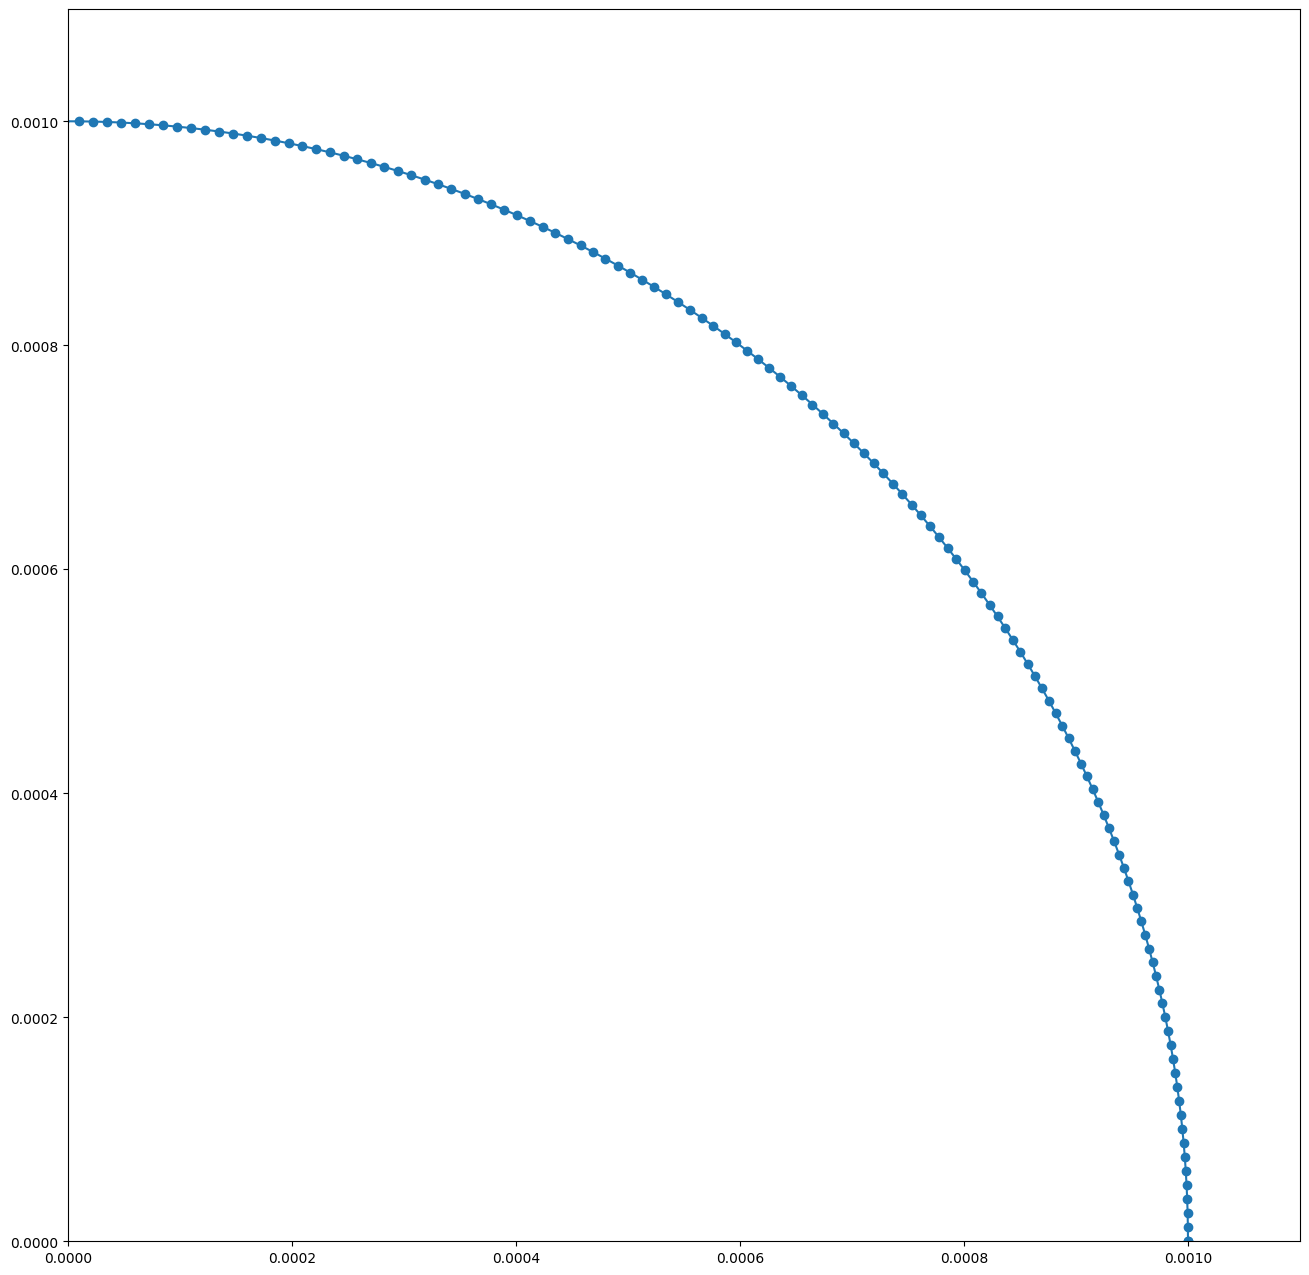

In [12]:
fig, ax = plt.subplots(figsize=(16,16))

ax.set_aspect('equal')

ax.set_xlim(0.0,1.1e-3)
ax.set_ylim(0.0,1.1e-3)

ax.plot(g1[:,0], g1[:,1], '-o', label='g1')
#ax.plot(g2[:,0], g2[:,1], '-o', label='g2')
#ax.plot(g3[:,0], g3[:,1], '-o', label='g3')

In [13]:
def generate_sphere(radius, N):
    """Generates the core (A half-disk in positive R for R-Z geometry)"""
    # Create a half-circle from -90 to +90 degrees (South to North pole)
    theta = np.linspace( 0.0, 2.*np.pi, N)
    R = radius * np.cos(theta)
    Z = radius * np.sin(theta)
    
    # Close the shape straight down along the Z axis (R=0)
    R = np.append(R, R[0])
    Z = np.append(Z, Z[0])

    df = pd.DataFrame({'R': R, 'Z': Z})

    df['R'] = - df['R']  # Flip R to be positive
    return df

def generate_shell(r_out, r_in, N):
    
    """Generates a hollow shell contour (A C-shape in positive R)"""
    
    theta = np.linspace( 0.0, 2.*np.pi, N)

    # Outer arc going up (from South to North pole)
    R_out = r_out * np.cos(theta)
    Z_out = r_out * np.sin(theta)
    
    # Inner arc going down (from North to South pole)
    R_in = r_in * np.cos(theta)
    Z_in = r_in * np.sin(theta)
    
    # Connect the outer and inner arcs to form a closed shell
    R_shell = np.concatenate([ R_out, R_in[::-1], [R_out[0]], ])
    Z_shell = np.concatenate([ Z_out, Z_in[::-1], [Z_out[0]], ])
    
    df = pd.DataFrame({'R': R_shell, 'Z': Z_shell})
    df['R'] = - df['R']  # Flip R to be positive
    return df

In [14]:
r1 = 1.e-3
r2 = 0.8e-3
r3 = 0.6e-3

N = 2000

g1 = generate_shell(r1, r2, N)
g2 = generate_shell(r2, r3, N)
g3 = generate_sphere(r3, N)

print(g1.shape)
print(g2.shape)
print(g3.shape)

(4001, 2)
(4001, 2)
(2001, 2)


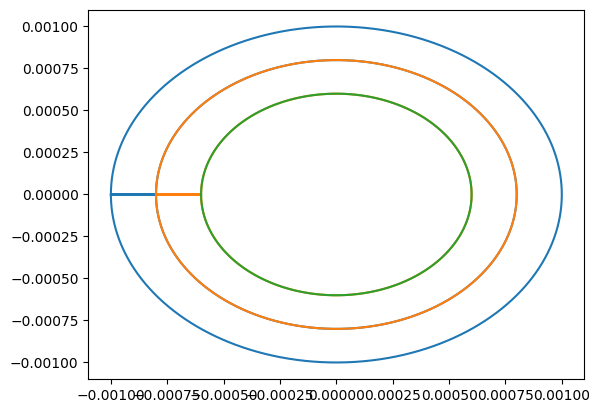

In [15]:
fig, ax = plt.subplots()

ax.plot(g1['R'], g1['Z'], label='g1')
ax.plot(g2['R'], g2['Z'], label='g2')
ax.plot(g3['R'], g3['Z'], label='g3')

In [16]:
s1 = '\n'.join([f'{R:15.7e} {Z:15.7e}' for R, Z in zip(g1['R'], g1['Z'])])
s2 = '\n'.join([f'{R:15.7e} {Z:15.7e}' for R, Z in zip(g2['R'], g2['Z'])])
s3 = '\n'.join([f'{R:15.7e} {Z:15.7e}' for R, Z in zip(g3['R'], g3['Z'])])

In [18]:
print(s1 + '\n' + s2 + '\n' + s3,file=open('g1g2g3.txt','w'))